<a href="https://colab.research.google.com/github/Deeksha1803/DeepFakeDetection/blob/main/deepfake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install mtcnn opencv-python Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.6 MB/s eta 0:00:00


In [ ]:
input_root = "/content/drive/My Drive/deepfake_project/datasets/celeb_df"
output_root = "/content/drive/My Drive/deepfake_project/datasets/preprocessed"


In [ ]:
import cv2
import os
from mtcnn import MTCNN
from PIL import Image

def extract_faces_from_video(video_path, output_folder, every_n_frames=10):
    detector = MTCNN()
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % every_n_frames == 0:
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            faces = detector.detect_faces(rgb_frame)

            for i, face in enumerate(faces):
                x, y, w, h = face['box']
                x, y = max(0, x), max(0, y)
                face_img = rgb_frame[y:y+h, x:x+w]

                if face_img.size == 0:
                    continue

                face_img = Image.fromarray(face_img).resize((160, 160))
                save_path = os.path.join(output_folder, f"{video_name}_{frame_count}_{i}.jpg")
                face_img.save(save_path)
                saved_count += 1

        frame_count += 1

    cap.release()
    print(f"[{video_name}] Extracted {saved_count} faces.")


def process_all_videos(input_folder, output_folder, label):
    video_folder = os.path.join(input_folder, label)
    output_label_folder = os.path.join(output_folder, label)
    os.makedirs(output_label_folder, exist_ok=True)

    for filename in os.listdir(video_folder):
        if filename.endswith(".mp4"):
            video_path = os.path.join(video_folder, filename)
            extract_faces_from_video(video_path, output_label_folder)


# Run for both real and fake
process_all_videos(input_root, output_root, "real")
process_all_videos(input_root, output_root, "fake")


[id7_0000] Extracted 29 faces.
[id6_0008] Extracted 39 faces.
[id6_0009] Extracted 53 faces.
[id6_0005] Extracted 39 faces.
[id6_0007] Extracted 61 faces.
[id6_0006] Extracted 32 faces.
[id9_0009] Extracted 33 faces.
[id9_0007] Extracted 46 faces.
[id9_0006] Extracted 41 faces.
[id9_0008] Extracted 48 faces.
[id9_id3_0000] Extracted 45 faces.
[id9_id3_0001] Extracted 44 faces.
[id9_id6_0004] Extracted 37 faces.
[id9_id6_0009] Extracted 32 faces.
[id9_id6_0006] Extracted 42 faces.
[id9_id6_0005] Extracted 42 faces.
[id9_id6_0001] Extracted 44 faces.
[id9_id6_0007] Extracted 46 faces.
[id9_id6_0002] Extracted 41 faces.
[id9_id6_0008] Extracted 47 faces.


In [ ]:
!pip install tensorflow scikit-learn


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import LSTM, Dense, TimeDistributed, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split


In [ ]:
# Parameters
image_size = (160, 160)
sequence_length = 5
real_path = "/content/drive/My Drive/deepfake_project/datasets/preprocessed/real"
fake_path = "/content/drive/My Drive/deepfake_project/datasets/preprocessed/fake"

def load_sequences(folder, label):
    all_sequences = []
    all_labels = []

    filenames = sorted([f for f in os.listdir(folder) if f.endswith('.jpg')])

    for i in range(0, len(filenames) - sequence_length, sequence_length):
        sequence = []
        for j in range(sequence_length):
            img_path = os.path.join(folder, filenames[i + j])
            img = load_img(img_path, target_size=image_size)
            img = img_to_array(img) / 255.0
            sequence.append(img)
        all_sequences.append(sequence)
        all_labels.append(label)

    return np.array(all_sequences), np.array(all_labels)

# Load real and fake sequences
real_seq, real_labels = load_sequences(real_path, label=1)
fake_seq, fake_labels = load_sequences(fake_path, label=0)

# Combine and split
X = np.concatenate((real_seq, fake_seq), axis=0)
y = np.concatenate((real_labels, fake_labels), axis=0)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
# Base ResNet50 model (no top, pretrained)
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(160, 160, 3))

# Freeze ResNet layers
resnet_base.trainable = False

# Model
model = Sequential([
    TimeDistributed(resnet_base, input_shape=(sequence_length, 160, 160, 3)),
    TimeDistributed(GlobalAveragePooling2D()),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 5, 5, 2048)  │    23,587,712 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 2048)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       540,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,132,865 (92.06 MB)

 Trainable params: 545,153 (2.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=4,
    validation_data=(X_val, y_val)
)



Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.5165 - loss: 0.7059 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.4904 - loss: 0.6989 - val_accuracy: 0.5000 - val_loss: 0.6968
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.4967 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.4889 - loss: 0.6965 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.4629 - loss: 0.6976 - val_accuracy: 0.5000 - val_loss: 0.6931


In [ ]:
model.save('/content/drive/My Drive/deepfake_project/models/deepfake_detector.h5')


In [ ]:
!pip install telepot
import telepot


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for telepot: filename=telepot-12.7-py3-none-any.whl size=57941 sha256=cc5a08c322bd7af78d76b11a5df491eebb72d4c84eb4b7cf7ddd9fb1000c8b99
  Stored in directory: /root/.cache/pip/wheels/48/5b/e8/bd84ac4d3edf2378b9bc22049d151a6c28e47cab24eae496cf
Successfully built telepot


In [ ]:
# Replace these with your real bot token and chat ID
BOT_TOKEN = 'YOUR_BOT_TOKEN'
CHAT_ID = 'YOUR_TELEGRAM_USER_ID'

def send_telegram_alert(prediction):
    if prediction < 0.88:  # adjust threshold if needed
        message = "⚠️ DeepFake Detected!"
    else:
        message = "✅ Real Content Detected."

    bot = telepot.Bot(BOT_TOKEN)
    bot.sendMessage(CHAT_ID, message)


In [ ]:
import telepot

BOT_TOKEN = '8112183654:AAFtCU9nsHxmV1xT0qBW2a-uyJ8IYcFeSQE'
CHAT_ID = '6078559024'

def send_telegram_alert(prediction):
    if prediction < 0.88:
        message = "⚠️ DeepFake Detected!"
    else:
        message = "✅ Real Content Detected."

    bot = telepot.Bot(BOT_TOKEN)
    bot.sendMessage(CHAT_ID, message)


In [ ]:
# Simulated model output (you'll replace this with your real model output)
predicted_prob = 0.47  # Below 0.88 → DeepFake

# Trigger the alert
send_telegram_alert(predicted_prob)


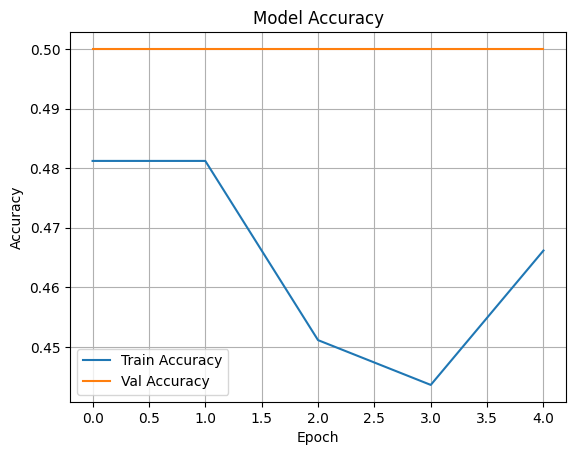

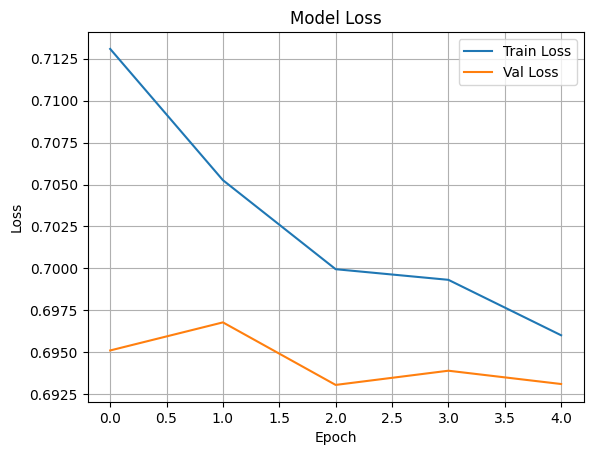

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
test_image_path = "/content/drive/My Drive/deepfake_project/test_samples/test1.jpg"

def predict_single_image(image_path):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    import numpy as np

    img = load_img(image_path, target_size=(160, 160))
    img = img_to_array(img) / 255.0
    sequence = np.expand_dims([img]*5, axis=0)  # create a 5-frame fake sequence

    pred = model.predict(sequence)[0][0]
    print(f"Prediction: {'Fake' if pred < 0.88 else 'Real'} (Score: {pred:.4f})")

    send_telegram_alert(pred)  # triggers alert

# Run the prediction
predict_single_image(test_image_path)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
Prediction: Fake (Score: 0.4946)


In [ ]:
def send_telegram_alert(prediction):
    if prediction < 0.75:  # more strict
        message = "⚠️ DeepFake Detected!"
    else:
        message = "✅ Real Content Detected."


In [ ]:
from google.colab import files
files.download("/content/drive/My Drive/deepfake_project/models/deepfake_detector.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>